In [22]:
from pathlib import Path
import json
import os
import shutil
import subprocess
import sys
import urllib.request

In [23]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
CHUNKS_DIR = DATA_DIR / "chunks"
MODEL_DIR = DATA_DIR / "vncorenlp"
STOPWORDS_PATH = RAW_DIR / "vietnamese-stopwords.txt"

for directory in [RAW_DIR, PROCESSED_DIR, CHUNKS_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data dir: {RAW_DIR}")
print(f"Processed data dir: {PROCESSED_DIR}")
print(f"Chunks dir: {CHUNKS_DIR}")

Project root: d:\projects\vietnamese-news-search-engine\data\vncorenlp
Raw data dir: d:\projects\vietnamese-news-search-engine\data\vncorenlp\data\raw
Processed data dir: d:\projects\vietnamese-news-search-engine\data\vncorenlp\data\processed
Chunks dir: d:\projects\vietnamese-news-search-engine\data\vncorenlp\data\chunks


In [24]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import kagglehub
except ModuleNotFoundError:
    kagglehub = None

In [25]:
raw_json_path = RAW_DIR / "news_dataset.json"

if not raw_json_path.exists():
    if kagglehub is None:
        raise ModuleNotFoundError(
            "Missing kagglehub and data/raw/news_dataset.json does not exist. "
            "Install with `pip install kagglehub` or place news_dataset.json in data/raw."
        )

    downloaded_dir = Path(kagglehub.dataset_download("haitranquangofficial/vietnamese-online-news-dataset"))
    source_json_path = downloaded_dir / "news_dataset.json"
    if not source_json_path.exists():
        raise FileNotFoundError(f"Cannot find news_dataset.json in downloaded folder: {downloaded_dir}")

    shutil.copy2(source_json_path, raw_json_path)
    print(f"Downloaded raw dataset to: {raw_json_path}")
else:
    print(f"Using local raw dataset: {raw_json_path}")

df = pd.read_json(raw_json_path)
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Downloaded raw dataset to: d:\projects\vietnamese-news-search-engine\data\vncorenlp\data\raw\news_dataset.json
Loaded dataset: 184539 rows, 10 columns


In [26]:
raw_pickle_path = RAW_DIR / "news_dataset_df.pkl"
df.to_pickle(raw_pickle_path)

print(f"DataFrame saved to: {raw_pickle_path}")

DataFrame saved to: d:\projects\vietnamese-news-search-engine\data\vncorenlp\data\raw\news_dataset_df.pkl


In [27]:
raw_pickle_path = RAW_DIR / "news_dataset_df.pkl"

if raw_pickle_path.exists():
    df = pd.read_pickle(raw_pickle_path)
    print(f"DataFrame loaded from: {raw_pickle_path}")
else:
    df = pd.read_json(RAW_DIR / "news_dataset.json")
    print(f"DataFrame loaded from JSON: {RAW_DIR / 'news_dataset.json'}")

print(f"Loaded DataFrame shape: {df.shape}")

DataFrame loaded from: d:\projects\vietnamese-news-search-engine\data\vncorenlp\data\raw\news_dataset_df.pkl
Loaded DataFrame shape: (184539, 10)


In [28]:
df.head()

,id,author,content,picture_count,processed,source,title,topic,url,crawled_at
0,218270,,"Chiều 31/7, Công an tỉnh Thừa Thiên - Huế đã c...",3,0,docbao.vn,"Tên cướp tiệm vàng tại Huế là đại uý công an, ...",Pháp luật,https://docbao.vn/phap-luat/ten-cuop-tiem-vang...,2022-08-01 09:09:22.817308
1,218269,(Nguồn: Sina),"Gần đây, Thứ trưởng Bộ Phát triển Kỹ thuật số,...",1,0,vtc.vn,"Bỏ qua mạng 5G, Nga tiến thẳng từ 4G lên 6G",Sống kết nối,https://vtc.vn/bo-qua-mang-5g-nga-tien-thang-t...,2022-08-01 09:09:21.181469
2,218268,Hồ Sỹ Anh,Kết quả thi tốt nghiệp THPT năm 2022 cho thấy ...,3,0,thanhnien.vn,Địa phương nào đứng đầu cả nước tổng điểm 3 mô...,Giáo dục,https://thanhnien.vn/dia-phuong-nao-dung-dau-c...,2022-08-01 09:09:15.311901
3,218267,Ngọc Ánh,Thống đốc Kentucky Andy Beshear hôm 31/7 cho h...,1,0,vnexpress,Người chết trong mưa lũ 'nghìn năm có một' ở M...,Thế giới,https://vnexpress.net/nguoi-chet-trong-mua-lu-...,2022-08-01 09:09:02.211498
4,218266,HẢI YẾN - MINH LÝ,Vụ tai nạn giao thông liên hoàn trên phố đi bộ...,12,0,soha,"Hải Phòng: Hình ảnh xe ""điên"" gây tai nạn liên...",Thời sự - Xã hội,https://soha.vn/hai-phong-hinh-anh-xe-dien-gay...,2022-08-01 09:09:01.601170


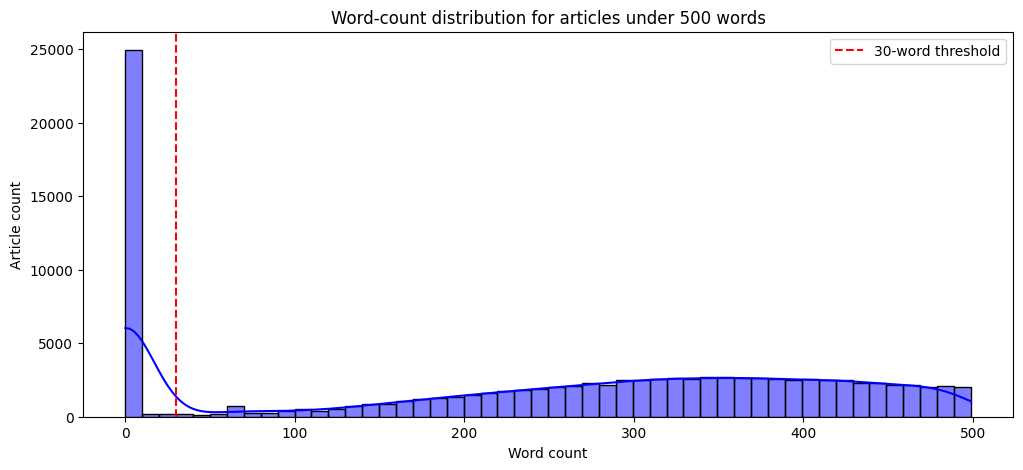


[STATS]
Total articles: 184539
Articles shorter than 100 chars: 24281 (13.16%)
--------------------------------------------------
Article 119215 | Length: 0 chars, 0 words
Title: Culture Mosaic - 02/7/2022 - Video đã phát trên VTV4 | VTV.VN
Content: 
--------------------------------------------------
Article 54040 | Length: 0 chars, 0 words
Title: Đau đầu ứng phó "bão giá"
Content: 
--------------------------------------------------
Article 99112 | Length: 0 chars, 0 words
Title: Lukaku đọc thơ Shakespeare khiến CĐV Chelsea nóng mặt | VTV.VN
Content: 
--------------------------------------------------
Article 94219 | Length: 0 chars, 0 words
Title: Bảo mẫu mải xem điện thoại, bé 2 tuổi rơi từ tầng 8 xuống ở Trung Quốc
Content: 
--------------------------------------------------
Article 51104 | Length: 0 chars, 0 words
Title: Phim tài liệu: Sứ mệnh bảo vệ cuộc sống bình yên
Content: 
--------------------------------------------------
Article 1906 | Length: 0 chars, 0 words
Title: Vị tr

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

content_col = "content"
df[content_col] = df[content_col].fillna("")

# Count characters and words per article.
df["char_count"] = df[content_col].apply(len)
df["word_count"] = df[content_col].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 5))
sns.histplot(df[df["word_count"] < 500]["word_count"], bins=50, kde=True, color="blue")
plt.title("Word-count distribution for articles under 500 words")
plt.xlabel("Word count")
plt.ylabel("Article count")
plt.axvline(x=30, color="red", linestyle="--", label="30-word threshold")
plt.legend()
plt.show()

threshold_char = 100
short_df = df[df["char_count"] < threshold_char]

print("\n[STATS]")
print(f"Total articles: {len(df)}")
print(f"Articles shorter than {threshold_char} chars: {len(short_df)} ({len(short_df) / len(df) * 100:.2f}%)")

sample_size = min(20, len(short_df))

if sample_size > 0:
    samples = short_df.sample(sample_size, random_state=42)

    for idx, row in samples.iterrows():
        print("-" * 50)
        print(f"Article {idx} | Length: {row['char_count']} chars, {row['word_count']} words")
        print(f"Title: {row['title']}")
        print(f"Content: {row[content_col]}")
else:
    print("No article is shorter than this threshold.")

Nhận xét: nếu chúng ta giữ lại 13.16% dữ liệu rác này, hệ thống tính toán TF-IDF và thuật toán BM25 sau này sẽ bị phình to vô ích, Thuật toán BM25 và TF-IDF đều dựa vào tổng số lượng tài liệu trong tập dữ liệu ($N$) để phạt/thưởng các từ khóa. Việc có thêm 24 ngàn bài "rỗng" sẽ làm sai lệch nghiêm trọng trọng số tài liệu nghịch đảo (IDF) của mô hình.

##Tiền xử lý 

### VncoreNLP

In [ ]:
import importlib
import subprocess
import sys
import urllib.request


def ensure_package(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        return importlib.import_module(module_name)
    except ModuleNotFoundError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        return importlib.import_module(module_name)


py_vncorenlp = ensure_package("py_vncorenlp")
ensure_package("tqdm")

stopwords_url = "https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt"
if not STOPWORDS_PATH.exists():
    urllib.request.urlretrieve(stopwords_url, STOPWORDS_PATH)
    print(f"Downloaded stopwords to: {STOPWORDS_PATH}")
else:
    print(f"Using local stopwords: {STOPWORDS_PATH}")

In [ ]:
import py_vncorenlp
import re
import string
import unicodedata
import sys
from urllib.request import Request, urlopen


def configure_java_home():
    if os.environ.get("JAVA_HOME"):
        print(f"JAVA_HOME: {os.environ['JAVA_HOME']}")
        return

    candidates = []
    if sys.platform == "win32":
        for root in [
            Path(r"C:\Program Files\Java"),
            Path(r"C:\Program Files\Eclipse Adoptium"),
            Path(r"C:\Program Files\Microsoft"),
        ]:
            if root.exists():
                candidates.extend(sorted(root.glob("jdk*"), reverse=True))

    for candidate in candidates:
        java_exe = candidate / "bin" / "java.exe"
        javac_exe = candidate / "bin" / "javac.exe"
        if java_exe.exists() and javac_exe.exists():
            os.environ["JAVA_HOME"] = str(candidate)
            os.environ["PATH"] = str(candidate / "bin") + os.pathsep + os.environ.get("PATH", "")
            print(f"JAVA_HOME set to: {candidate}")
            return

    raise EnvironmentError(
        "Unable to find JAVA_HOME. Install a JDK, then set JAVA_HOME to the JDK folder, "
        "for example: C:\\Program Files\\Java\\jdk-17"
    )


configure_java_home()


def download_file(url, destination):
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)

    if destination.exists() and destination.stat().st_size > 0:
        return

    print(f"Downloading {destination.name}...")
    request = Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urlopen(request) as response, open(destination, "wb") as output:
        shutil.copyfileobj(response, output)


VNCORENLP_BASE_URL = "https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master"
VNCORENLP_FILES = {
    "VnCoreNLP-1.2.jar": f"{VNCORENLP_BASE_URL}/VnCoreNLP-1.2.jar",
    "models/wordsegmenter/vi-vocab": f"{VNCORENLP_BASE_URL}/models/wordsegmenter/vi-vocab",
    "models/wordsegmenter/wordsegmenter.rdr": f"{VNCORENLP_BASE_URL}/models/wordsegmenter/wordsegmenter.rdr",
    "models/postagger/vi-tagger": f"{VNCORENLP_BASE_URL}/models/postagger/vi-tagger",
    "models/ner/vi-500brownclusters.xz": f"{VNCORENLP_BASE_URL}/models/ner/vi-500brownclusters.xz",
    "models/ner/vi-ner.xz": f"{VNCORENLP_BASE_URL}/models/ner/vi-ner.xz",
    "models/ner/vi-pretrainedembeddings.xz": f"{VNCORENLP_BASE_URL}/models/ner/vi-pretrainedembeddings.xz",
    "models/dep/vi-dep.xz": f"{VNCORENLP_BASE_URL}/models/dep/vi-dep.xz",
}

for relative_path, url in VNCORENLP_FILES.items():
    download_file(url, MODEL_DIR / relative_path)

rdrsegmenter = py_vncorenlp.VnCoreNLP(annotators=["wseg"], save_dir=str(MODEL_DIR))
print(f"Loaded VnCoreNLP from: {MODEL_DIR}")

In [ ]:
def normalize_date(text):
    pattern_dmy = r"\b(\d{1,2})[-/.](\d{1,2})[-/.](\d{2,4})\b"
    pattern_dm = r"\b(\d{1,2})[-/.](\d{1,2})\b"

    def repl_dmy(m):
        day, month, year = m.groups()
        if len(year) == 2:
            year = "20" + year
        return f" DATE{year}{int(month):02d}{int(day):02d} "

    def repl_dm(m):
        day, month = m.groups()
        return f" DATE{int(month):02d}{int(day):02d} "

    text = re.sub(pattern_dmy, repl_dmy, text)
    text = re.sub(pattern_dm, repl_dm, text)
    return text


def clean_text_keep_case(text):
    text = str(text)
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b", " ", text)
    text = normalize_date(text)

    custom_punctuation = string.punctuation.replace("_", "").replace("-", "")
    translator = str.maketrans(custom_punctuation, " " * len(custom_punctuation))
    text = text.translate(translator)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def preprocess_pipeline_v2(text):
    if not isinstance(text, str):
        return ""

    if len(text.strip()) == 0:
        return ""

    cleaned = clean_text_keep_case(text)
    segmented_sentences = rdrsegmenter.word_segment(cleaned)
    tokenized_text = " ".join(segmented_sentences).lower()

    return tokenized_text

In [ ]:
from tqdm.auto import tqdm

In [ ]:
from tqdm.auto import tqdm
import time

tqdm.pandas()

start_time = time.time()

df_prep2 = df.copy()
df_prep2["title"] = df_prep2["title"].fillna("")
content_col = "content"
df_prep2[content_col] = df_prep2[content_col].fillna("")

# Remove very short articles.
df_prep2 = df_prep2[df_prep2[content_col].str.len() > 100].copy()

# Process title and content separately for multi-field search.
df_prep2["title_processed"] = df_prep2["title"].progress_apply(preprocess_pipeline_v2)
df_prep2["content_processed"] = df_prep2[content_col].progress_apply(preprocess_pipeline_v2)
df_prep2["combined_processed"] = df_prep2["title_processed"] + " " + df_prep2["content_processed"]

end_time = time.time()
print(f"Processed {df_prep2.shape[0]} articles in {round(end_time - start_time, 2)} seconds.")

In [ ]:
# test thÃƒÂ¡Ã‚Â»Ã‚Â­ cÃƒÆ’Ã‚Â¡i cÃƒÂ¡Ã‚Â»Ã‚Â§a th bÃƒÂ¡Ã‚ÂºÃ‚Â£o

df_prep2[df_prep2['id'] == 218229]['combined_processed'].iloc[0]

### TÃƒÂ¡Ã‚ÂºÃ‚Â¡o cÃƒÂ¡Ã‚Â»Ã¢â€žÂ¢t khÃƒÆ’Ã‚Â´ng dÃƒÂ¡Ã‚ÂºÃ‚Â¥u

In [ ]:
import unicodedata


def remove_vn_accents(text):
    if not isinstance(text, str):
        return ""

    text = unicodedata.normalize("NFD", text)
    text = "".join([c for c in text if unicodedata.category(c) != "Mn"])
    text = text.replace("Ã„â€˜", "d").replace("Ã„Â", "D")

    return text

In [ ]:
df_prep2["combined_unaccented"] = df_prep2["combined_processed"].apply(remove_vn_accents)

In [ ]:
df_prep2[df_prep2['id'] == 218229]['combined_unaccented'].iloc[0]

In [ ]:
prep2_pickle_path = PROCESSED_DIR / "news_dataset_df_prep2.pkl"
df_prep2.to_pickle(prep2_pickle_path)

print(f"DataFrame df_prep2 saved to: {prep2_pickle_path}")

### BÃƒÂ¡Ã‚ÂºÃ‚Â£n cÃƒÆ’Ã‚Â³ Stopword

In [ ]:
df_prep3 = df_prep2.copy()

if not STOPWORDS_PATH.exists():
    raise FileNotFoundError(f"Stopwords file not found: {STOPWORDS_PATH}. Run the dependency cell first.")

with open(STOPWORDS_PATH, "r", encoding="utf-8") as f:
    stopwords_vn = set([line.strip().replace(" ", "_") for line in f])

print(f"Loaded {len(stopwords_vn)} stopwords")


def remove_stopwords(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""

    tokens = text.split()
    filtered_tokens = [token for token in tokens if token.lower() not in stopwords_vn]

    return " ".join(filtered_tokens)


df_prep3["title_processed"] = df_prep2["title_processed"].apply(remove_stopwords)
df_prep3["content_processed"] = df_prep2["content_processed"].apply(remove_stopwords)
df_prep3["combined_processed"] = df_prep3["title_processed"] + " " + df_prep3["content_processed"]

In [ ]:
df_prep3[df_prep3['id'] == 218229]['combined_processed'].iloc[0]

In [ ]:
total_before = df_prep2["combined_processed"].str.split().str.len().sum()
total_after = df_prep3["combined_processed"].str.split().str.len().sum()

print(total_before)
print(total_after)

In [ ]:
df_prep3["combined_unaccented"] = df_prep3["combined_processed"].apply(remove_vn_accents)

In [ ]:
prep3_pickle_path = PROCESSED_DIR / "news_dataset_df_prep3.pkl"
df_prep3.to_pickle(prep3_pickle_path)

print(f"DataFrame df_prep3 saved to: {prep3_pickle_path}")

### Chunking dÃƒÂ¡Ã‚Â»Ã‚Â¯ liÃƒÂ¡Ã‚Â»Ã¢â‚¬Â¡u cho giai Ãƒâ€žÃ¢â‚¬ËœoÃƒÂ¡Ã‚ÂºÃ‚Â¡n 4

In [ ]:
import pandas as pd
import json
import nltk
from nltk.tokenize import sent_tokenize
from tqdm import tqdm

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

def chunk_document_raw(title, content, window_size=4, overlap=1):
    title = str(title).strip()
    content = str(content).strip()
    sentences = sent_tokenize(content)

    if len(sentences) <= window_size:
        return [title + ". " + content]

    chunks = []
    i = 0
    while i < len(sentences):
        chunk_sentences = sentences[i : i + window_size]
        chunk_text = title + ". " + " ".join(chunk_sentences)
        chunks.append(chunk_text)
        i += (window_size - overlap)
        if i >= len(sentences) - overlap:
            break
    return chunks

In [ ]:
df_prep = df.copy()

df_prep["title"] = df_prep["title"].fillna("")
content_col = "content"
df_prep[content_col] = df_prep[content_col].fillna("")

original_len = len(df_prep)
df_prep = df_prep[df_prep[content_col].str.len() > 100].copy()

df_prep = df_prep.reset_index(drop=True)
df_prep["doc_id"] = df_prep.index.astype(str)

print(f"Removed {original_len - len(df_prep)} short articles. Kept {len(df_prep)} valid articles.")

export_chunks = []

for index, row in tqdm(df_prep.iterrows(), total=len(df_prep), desc="Processing chunks"):
    doc_id = row["doc_id"]
    url = row.get("url", "")
    topic = row.get("topic", "")
    title = row["title"]
    content = row[content_col]

    raw_chunks = chunk_document_raw(title, content, window_size=4, overlap=1)

    for chunk_idx, raw_chunk_text in enumerate(raw_chunks):
        chunk_id = f"{doc_id}_{chunk_idx}"
        chunk_processed = preprocess_pipeline_v2(raw_chunk_text)
        chunk_unaccented = remove_vn_accents(chunk_processed)

        export_chunks.append({
            "doc_id": doc_id,
            "chunk_id": chunk_id,
            "url": url,
            "topic": topic,
            "raw_text": raw_chunk_text,
            "chunk_processed": chunk_processed,
            "chunk_unaccented": chunk_unaccented,
        })

In [ ]:
demo_doc_id = export_chunks[0]['doc_id']
for item in export_chunks:
    if item['doc_id'] == demo_doc_id:
        print(f"{item['chunk_id']}")
        print(f"{item['chunk_processed']}")

In [ ]:
chunks_json_path = CHUNKS_DIR / "corpus_chunks.json"
with open(chunks_json_path, "w", encoding="utf-8") as f:
    json.dump(export_chunks, f, ensure_ascii=False, indent=2)

print(f"Saved {len(export_chunks)} chunks to: {chunks_json_path}")

In [ ]:
print(f"Chunks file is available at: {chunks_json_path}")

### HÃƒâ€ Ã‚Â°ÃƒÂ¡Ã‚Â»Ã¢â‚¬Âºng dÃƒÂ¡Ã‚ÂºÃ‚Â«n tÃƒÂ¡Ã‚ÂºÃ‚Â£i file xuÃƒÂ¡Ã‚Â»Ã¢â‚¬Ëœng trÃƒÆ’Ã‚Âªn colab cho mÃƒÆ’Ã‚Â¡y yÃƒÂ¡Ã‚ÂºÃ‚Â¿u (nhÃƒâ€ Ã‚Â°ng Ãƒâ€žÃ¢â‚¬Ëœc cÃƒÆ’Ã‚Â¡i mÃƒÂ¡Ã‚ÂºÃ‚Â¡ng mÃƒÂ¡Ã‚ÂºÃ‚Â¡nh)

In [ ]:
prep2_pickle_path = PROCESSED_DIR / "news_dataset_df_prep2.pkl"
if prep2_pickle_path.exists():
    df_load = pd.read_pickle(prep2_pickle_path)
    print(f"Loaded prep2 DataFrame from: {prep2_pickle_path}")
    print(f"Shape: {df_load.shape}")
else:
    print(f"File not found yet: {prep2_pickle_path}")

In [ ]:
chunks_json_path = CHUNKS_DIR / "corpus_chunks.json"
if chunks_json_path.exists():
    print(f"Chunks JSON exists: {chunks_json_path}")
else:
    print(f"Chunks JSON not found yet: {chunks_json_path}")

In [ ]:
prep3_pickle_path = PROCESSED_DIR / "news_dataset_df_prep3.pkl"
if prep3_pickle_path.exists():
    df_load2 = pd.read_pickle(prep3_pickle_path)
    print(f"Loaded prep3 DataFrame from: {prep3_pickle_path}")
    print(f"Shape: {df_load2.shape}")
else:
    print(f"File not found yet: {prep3_pickle_path}")

In [ ]:
prep2_pickle_path = PROCESSED_DIR / "news_dataset_df_prep2.pkl"

try:
    df_load = pd.read_pickle(prep2_pickle_path)
    print(f"DataFrame loaded from: {prep2_pickle_path}")
    print(f"Loaded DataFrame shape: {df_load.shape}")
except FileNotFoundError:
    print(f"Error: File not found at {prep2_pickle_path}. Run the preprocessing cells first.")
except Exception as e:
    print(f"Error loading DataFrame: {e}")

In [ ]:
df_load.head(1)

In [ ]:
df_load[df_load['id'] == 213638]['combined_processed'].iloc[0]

In [ ]:
prep3_pickle_path = PROCESSED_DIR / "news_dataset_df_prep3.pkl"

try:
    df_load2 = pd.read_pickle(prep3_pickle_path)
    print(f"DataFrame loaded from: {prep3_pickle_path}")
    print(f"Loaded DataFrame shape: {df_load2.shape}")
except FileNotFoundError:
    print(f"Error: File not found at {prep3_pickle_path}. Run the preprocessing cells first.")
except Exception as e:
    print(f"Error loading DataFrame: {e}")

In [ ]:
df_load2[df_load2['id'] == 213638]['combined_processed'].iloc[0]

XuÃƒÂ¡Ã‚ÂºÃ‚Â¥t file JSON Ãƒâ€žÃ¢â‚¬ËœÃƒÂ¡Ã‚Â»Ã†â€™ inverted index

In [ ]:
df_export = df_load.copy()
df_export = df_export.reset_index(drop=True)
df_export["doc_id"] = df_export.index.astype(str)

columns_to_export = [
    "doc_id",
    "url",
    "topic",
    "title",
    "content",
    "title_processed",
    "content_processed",
    "combined_processed",
    "combined_unaccented",
]

available_cols = [col for col in columns_to_export if col in df_export.columns]
export_data = df_export[available_cols].to_dict(orient="records")

output_file = DATA_DIR / "search_engine_corpus2.json"
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(export_data, f, ensure_ascii=False, indent=2)

print(f"Exported {len(export_data)} documents to: {output_file}")

In [ ]:
print(f"Corpus JSON is available at: {output_file}")

In [ ]:
demo_doc = export_data[0]
print(f"LÃƒÂ¡Ã‚ÂºÃ‚Â¥y bÃƒÆ’Ã‚Â i bÃƒÆ’Ã‚Â¡o: doc_id = {demo_doc['doc_id']}")

tokens = str(demo_doc['combined_processed']).split()
print(f"TÃƒÆ’Ã‚Â¡ch token: {tokens[:5]}...")

print("Ãƒâ€žÃ‚ÂÃƒâ€ Ã‚Â°a vÃƒÆ’Ã‚Â o Hash Map (Inverted Index):")
print(f"   - TÃƒÂ¡Ã‚Â»Ã‚Â« '{tokens[0]}' -> ThÃƒÆ’Ã‚Âªm doc_id {demo_doc['doc_id']} vÃƒÆ’Ã‚Â o danh sÃƒÆ’Ã‚Â¡ch")

LIKE AND SUBCRIBE cho VINH 30 CM

Ãƒâ€žÃ‚ÂÃƒÆ’Ã‚Â³ng gÃƒÆ’Ã‚Â³p:
- NguyÃƒÂ¡Ã‚Â»Ã¢â‚¬Â¦n ThÃƒÆ’Ã‚Â nh Vinh: 500 %
- ThÃƒÆ’Ã‚Â nh viÃƒÆ’Ã‚Âªn cÃƒÆ’Ã‚Â²n lÃƒÂ¡Ã‚ÂºÃ‚Â¡i: